/Users/alexanderdagher/.pyenv/versions/3.10.12/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/alexanderdagher/.pyenv/versions/3.10.12/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/alexanderdagher/.pyenv/versions/3.10.12/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/alexanderdagher/.pyenv/versions/3.10.12/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported 

Backtest MAE: 1.4941    RMSE: 3.2824


/Users/alexanderdagher/.pyenv/versions/3.10.12/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/alexanderdagher/.pyenv/versions/3.10.12/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/alexanderdagher/.pyenv/versions/3.10.12/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/alexanderdagher/.pyenv/versions/3.10.12/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported 

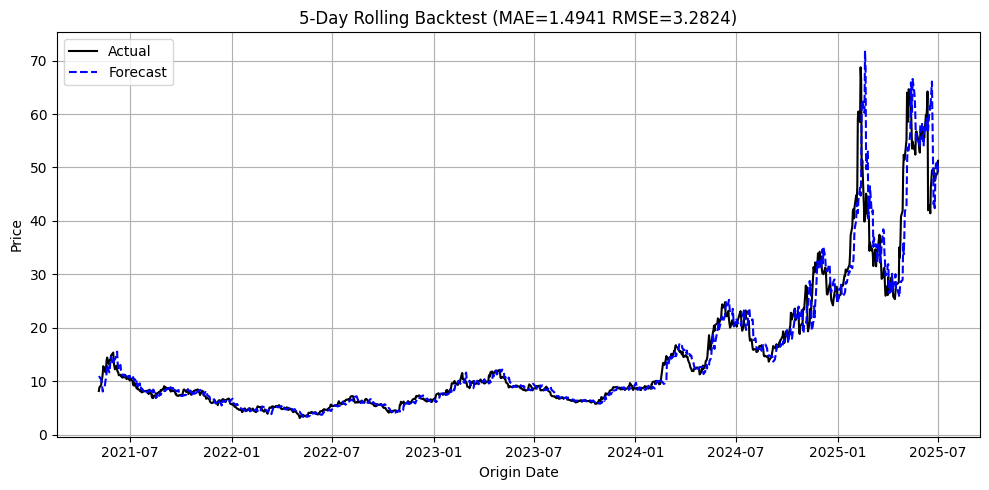

/Users/alexanderdagher/.pyenv/versions/3.10.12/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/alexanderdagher/.pyenv/versions/3.10.12/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/alexanderdagher/.pyenv/versions/3.10.12/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/alexanderdagher/.pyenv/versions/3.10.12/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported 

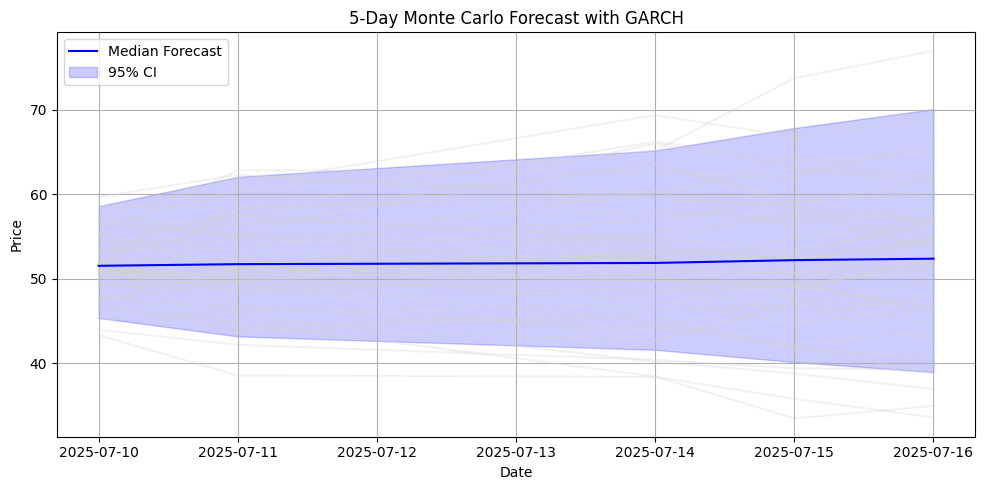

Saved Monte Carlo forecast to Forward_MonteCarlo_GARCH_Forecast.csv


In [2]:
# === INSTALL IF NEEDED ===
# pip install pandas numpy matplotlib statsmodels arch scikit-learn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from arch import arch_model
from sklearn.metrics import mean_absolute_error, mean_squared_error

# === CONFIGURATION ===
file_path       = "HIMS_Cleaned.csv"   # or "GOOG_C_cleaned.csv", etc.
window_size     = 350                  # days for each rolling fit
forecast_days   = 5                    # horizon in business days
simulations     = 5000                 # Monte Carlo paths
confidence_lvl  = 0.95                 # for bands in Option A

# === STEP 1: Load & preprocess ===
data   = pd.read_csv(file_path, parse_dates=['Date'])
data.sort_values('Date', inplace=True)
data.set_index('Date', inplace=True)
prices = data['Close']
rets   = np.log(prices / prices.shift(1)).dropna()

# === STEP 2: Option C — Rolling Backtest ===
origins, preds, actuals = [], [], []
for t in range(window_size, len(rets) - forecast_days + 1):
    # 2.1 Train
    train = rets[t-window_size : t]
    S0    = prices.iloc[t]

    # 2.2 ARIMA for μ₁…μ₅
    ar = sm.tsa.ARIMA(train, order=(1,0,0)).fit()
    mu = np.asarray(ar.forecast(steps=forecast_days))

    # 2.3 GARCH for σₜ (not used in point forecast)
    resid = ar.resid
    g     = arch_model(resid, vol='Garch', p=1, q=1).fit(disp='off')
    g_f   = g.forecast(horizon=forecast_days)
    sigma = np.sqrt(g_f.variance.values[-1])

    # 2.4 Analytical point‐forecast at horizon
    cum_mu     = mu.cumsum()
    forecast_p = S0 * np.exp(cum_mu[-1])
    actual_p   = prices.iloc[t + forecast_days]

    origins.append(prices.index[t])
    preds.append(forecast_p)
    actuals.append(actual_p)

backtest = pd.DataFrame({'Forecast': preds, 'Actual': actuals}, index=origins)

# Metrics
mae  = mean_absolute_error(backtest.Actual, backtest.Forecast)
rmse = np.sqrt(mean_squared_error(backtest.Actual, backtest.Forecast))
print(f"Backtest MAE: {mae:.4f}    RMSE: {rmse:.4f}")

# Plot Backtest
plt.figure(figsize=(10,5))
plt.plot(backtest.Actual,  label='Actual',  c='black')
plt.plot(backtest.Forecast, label='Forecast', c='blue', ls='--')
plt.title(f"5-Day Rolling Backtest (MAE={mae:.4f} RMSE={rmse:.4f})")
plt.xlabel("Origin Date"); plt.ylabel("Price")
plt.legend(); plt.grid(); plt.tight_layout()
plt.show()

# === STEP 3: Option A — Monte Carlo Forecast Today ===
# 3.1 Fit ARIMA+GARCH on last window
train = rets[-window_size:]
S0    = prices.iloc[-1]

ar_fwd = sm.tsa.ARIMA(train, order=(1,0,0)).fit()
mu_fwd = np.asarray(ar_fwd.forecast(steps=forecast_days))

resid_fwd = ar_fwd.resid
g_fwd     = arch_model(resid_fwd, vol='Garch', p=1, q=1).fit(disp='off')\
                .forecast(horizon=forecast_days)
sigma_fwd = np.sqrt(g_fwd.variance.values[-1])

# 3.2 Monte Carlo simulate price paths
sim_paths = np.zeros((simulations, forecast_days))
for t in range(forecast_days):
    sim_paths[:, t] = np.random.normal(loc=mu_fwd[t],
                                       scale=sigma_fwd[t],
                                       size=simulations)
# convert log-return matrix to price matrix
sim_prices = S0 * np.exp(np.cumsum(sim_paths, axis=1))

# 3.3 Summarize
dates       = pd.date_range(start=prices.index[-1] + pd.Timedelta(1,'D'),
                            periods=forecast_days, freq='B')
median_p    = np.median(sim_prices, axis=0)
low_band    = np.percentile(sim_prices, (1-confidence_lvl)/2*100, axis=0)
high_band   = np.percentile(sim_prices, (1+confidence_lvl)/2*100, axis=0)

mc_forecast = pd.DataFrame({
    'MedianPrice':    median_p,
    f'Lower_{int((1-confidence_lvl)/2*100)}%': low_band,
    f'Upper_{int((1+confidence_lvl)/2*100)}%': high_band
}, index=dates)

# Plot Monte Carlo fan chart
plt.figure(figsize=(10,5))
# plot some sample paths
for i in range(50):
    plt.plot(dates, sim_prices[i], c='lightgray', alpha=0.3)
plt.plot(dates, median_p,  c='blue', label='Median Forecast')
plt.fill_between(dates, low_band, high_band, color='blue', alpha=0.2,
                 label=f'{int(confidence_lvl*100)}% CI')
plt.title(f"{forecast_days}-Day Monte Carlo Forecast with GARCH")
plt.xlabel("Date"); plt.ylabel("Price")
plt.legend(); plt.grid(); plt.tight_layout()
plt.show()

# 3.4 Save forward forecasts
mc_forecast.to_csv("Forward_MonteCarlo_GARCH_Forecast.csv")
print("Saved Monte Carlo forecast to Forward_MonteCarlo_GARCH_Forecast.csv")
